## Data science project on predicting game sales

There are various factors which would affect game sales whether it is the year games were sold due to access to PC or consoles being limited in the past or if the games scores rated by players where a good game naturally sells well. We will take a deeper dive to see how these correlate and create a model to predict future game sales on various factors.

Key things to note about the limitations of this dataset:
- The dataset only covers up to December 2016.
- We will also ignore the price of games as this fluctuates over time, we will be looking at sales figures instead which are presented in millions.

First we want to import the dataset and take a look at how the data looks like, let's import this using pyspark to test it is working I have recently installed this for personal learning. We can convert this back into a pandas data frame after.

In [117]:
from pyspark.context import SparkContext
from pyspark.sql.session import SparkSession
import pandas as pd

sc = SparkContext.getOrCreate()
spark = SparkSession(sc)

df = spark.read.csv(
                    "Video_Games_Sales_as_at_22_Dec_2016.csv", 
                    header=True, mode="DROPMALFORMED", 
                    inferSchema=True
                    )

game_df = df.select("*").toPandas()

game_df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,None,NaN,None,None
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,None,NaN,None,None


Now let's take a look at the statistics of the dataset let's see total rows and see if there are anything missing.

In [118]:
display(game_df.info())

display(game_df.describe())

display(game_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16719 non-null  object 
 3   Genre            16717 non-null  object 
 4   Publisher        16719 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(8), object(8)
memory usage: 2.0+ MB


None

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


Name                  2
Platform              0
Year_of_Release       0
Genre                 2
Publisher             0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

Seems like there are some issues with the data let's remove the rows which are not helpful, what I can see if a couple of rows with no name and mostly empty fields let's get rid of those.

We also want to remove any non numerical columns along with the sales columns except for one we are predicting as global is equal to all others combined.

In [ ]:
game_df = game_df.dropna(subset=['Name'])

game_df = game_df.drop(columns=['Name', 'Platform', 'Genre', 'Publisher', 'Developer', 'Rating', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])

display(game_df.isnull().sum())

Year_of_Release       0
Global_Sales          0
Critic_Score       8580
Critic_Count       8580
User_Score         6702
User_Count         9127
dtype: int64

There are also various values of for 'blank' values instead of NaN values let's replace those to make sure these aren't detected as string values and convert them into floats.

In [120]:
import numpy as np

game_df = game_df.replace('None', np.nan).replace('N/A', np.nan).replace('nan', np.nan).replace([None], np.nan).replace('tbd', np.nan)

#Go through the columns and check for null values and add to the replace list above if any are found.
#display(game_df['Year_of_Release'].unique())

game_df = game_df.apply(pd.to_numeric, errors='ignore')

display(game_df.info())



<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year_of_Release  16448 non-null  float64
 1   Global_Sales     16717 non-null  float64
 2   Critic_Score     8137 non-null   float64
 3   Critic_Count     8137 non-null   float64
 4   User_Score       7590 non-null   float64
 5   User_Count       7590 non-null   float64
dtypes: float64(6)
memory usage: 914.2 KB


C:\Users\Michael Choi\AppData\Local\Temp\ipykernel_23068\1201003908.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  game_df = game_df.apply(pd.to_numeric, errors='ignore')


None

Much better let's take a look at the correlations between the numerical values

,Year_of_Release,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
Year_of_Release,1.000000,0.002447,-0.011215,0.197043,-0.251482,0.196867
Global_Sales,0.002447,1.000000,0.237083,0.290676,0.088406,0.263991
Critic_Score,-0.011215,0.237083,1.000000,0.394893,0.579671,0.265531
Critic_Count,0.197043,0.290676,0.394893,1.000000,0.194691,0.365505
User_Score,-0.251482,0.088406,0.579671,0.194691,1.000000,0.018505
User_Count,0.196867,0.263991,0.265531,0.365505,0.018505,1.000000


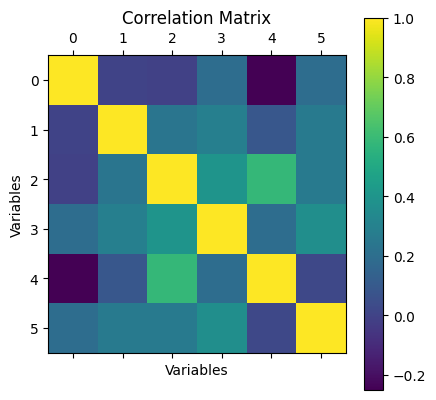

In [132]:
display(game_df.corr(numeric_only=True))

#Seems like global sales is most correlated with critic count, user score, and user count. Let's visualize these relationships in a correlation matrix.

import matplotlib.pyplot as plt

plt.matshow(game_df.corr(numeric_only=True))
plt.colorbar()
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.title('Correlation Matrix')
plt.show()

Seems like the correlation between the columns with missing values are relatively weak and the amount of columns with empty fields make up almost half of the dataset so imputing such large amount of values won't give helpful results so let's drop them for columns we are interested in using.

In [122]:
game_df = game_df.dropna(subset=game_df.loc[0, 'Year_of_Release':'User_Score'].index)

display(game_df.isnull().sum())

display(game_df.describe())

Year_of_Release    0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
dtype: int64

,Year_of_Release,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,6894.000000,6894.000000,6894.000000,6894.000000,6894.000000,6894.000000
mean,2007.482303,0.771487,70.258486,28.842472,7.184378,174.392370
std,4.236401,1.954780,13.861082,19.194572,1.439806,584.872155
min,1985.000000,0.010000,13.000000,3.000000,0.500000,4.000000
25%,2004.000000,0.110000,62.000000,14.000000,6.500000,11.000000
50%,2007.000000,0.290000,72.000000,24.000000,7.500000,27.000000
75%,2011.000000,0.750000,80.000000,39.000000,8.200000,89.000000
max,2016.000000,82.530000,98.000000,113.000000,9.600000,10665.000000


Next step would be to get the data ready by separating our dependent variable y and the independent variables x.

In [123]:
x = game_df.drop("Global_Sales", axis=1)

y = game_df["Global_Sales"]

display(x)

display(y)

,Year_of_Release,Critic_Score,Critic_Count,User_Score,User_Count
0,2006.0,76.0,51.0,8.0,322.0
2,2008.0,82.0,73.0,8.3,709.0
3,2009.0,80.0,73.0,8.0,192.0
6,2006.0,89.0,65.0,8.5,431.0
7,2006.0,58.0,41.0,6.6,129.0
...,...,...,...,...,...
16677,2002.0,81.0,12.0,8.8,9.0
16696,2014.0,80.0,20.0,7.6,412.0
16700,2011.0,61.0,12.0,5.8,43.0
16706,2011.0,60.0,12.0,7.2,13.0


0        82.53
2        35.52
3        32.77
6        29.80
7        28.92
         ...  
16677     0.01
16696     0.01
16700     0.01
16706     0.01
16709     0.01
Name: Global_Sales, Length: 6894, dtype: float64

Now we need to split out the data into two sets one for training and other for testing.

In [124]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

We will be using a linear regression model to predict the global sales after taking a look at the sci kit learn machine learning map to look for the right model.
https://scikit-learn.org/1.3/tutorial/machine_learning_map/

We will then fit the data into the model and make predictions on the test data

In [125]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = LinearRegression()

model.fit(x_train, y_train)

predictions = model.predict(x_test)

print("Mean Squared Error:", mean_squared_error(y_test, predictions))
print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("R^2 Score:", r2_score(y_test, predictions))

Mean Squared Error: 1.5776013689962274
Mean Absolute Error: 0.6782141068146894
R^2 Score: 0.3300958454728793


This results in a model with an R^2 score of 0.31 which means we have a reasonable chance of predicting a games sales given we know the critic and users scores and number of ratings.